# Conformal factor iteration (brute-force)

This notebook demonstrates the iteration from the pasted algorithm, using a brute-force $O(N^2)$ particle-particle summation in place of FMM.

Outputs:
- Convergence diagnostics
- A 1D slice of $\psi$ along the $x$-axis

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Robustly add the project root to sys.path so we can import from ./src
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
project_root = None
for p in candidates:
    if (p / 'src' / 'conformal_solver.py').exists():
        project_root = p
        break
if project_root is None:
    raise FileNotFoundError("Could not find src/conformal_solver.py from current working directory")
sys.path.insert(0, str(project_root))

from src.conformal_solver import ConformalFactorSolver  # noqa: E402

In [ ]:
# Step 1: create a discrete cloud of interpolation points.
# For this demo we use a small uniform Cartesian grid in a box.
L = 2.0
n = 15  # keep small; brute-force is O(N^2)
xs = np.linspace(-L, L, n)
dx = xs[1] - xs[0]
X, Y, Z = np.meshgrid(xs, xs, xs, indexing='ij')
r = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])

volumes = np.full(r.shape[0], dx**3)

# Define a toy potential V(r).
# Use a smooth compact-ish bump via a Gaussian truncated by the box.
sigma = 0.5
r2 = np.sum(r*r, axis=1)
V = np.exp(-r2 / (2*sigma**2))

# Optional: emulate 'support where V != 0' by dropping tiny values
eps = 1e-6
mask = V > eps
r_c = r[mask]
V_c = V[mask]
vol_c = volumes[mask]

r.shape, r_c.shape

((2744, 3), (2272, 3))

In [5]:
# Run the iteration (steps 4-11).
M = 1.0
solver = ConformalFactorSolver(r_c, V_c, vol_c, M=M, softening=0.5*dx, exclude_self=True)

psi, info = solver.solve(tol=1e-11, max_iter=200, error_norm='linf', verbose=True)
chi = psi - 1.0

info, psi.min(), psi.max()

iter    0  err=7.523e-01
iter    1  err=2.795e-03
iter    2  err=4.196e-04
iter    3  err=6.215e-05
iter    4  err=9.171e-06
iter    5  err=1.352e-06
iter    6  err=1.991e-07
iter    7  err=2.933e-08
iter    8  err=4.319e-09
iter    9  err=6.361e-10
iter   10  err=9.367e-11
iter   11  err=1.380e-11
iter   12  err=2.032e-12


(ConvergenceInfo(iterations=13, converged=True, last_error=2.031735890639652e-12),
 np.float64(-9.284404826952127),
 np.float64(-1.4534667134784263))

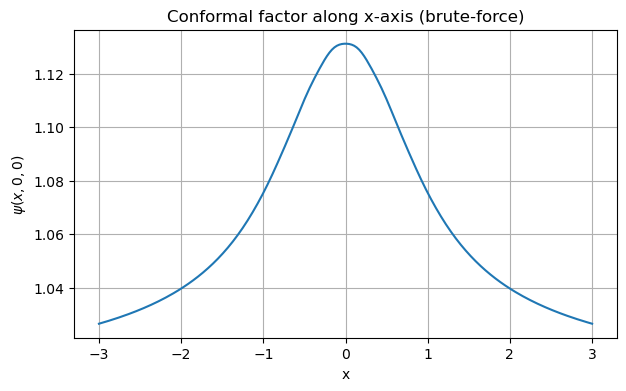

In [6]:
# Step 12: evaluate psi along the x-axis at y=z=0 using brute-force summation.
K = 200
xline = np.linspace(-3.0, 3.0, K)
r_eval = np.column_stack([xline, np.zeros_like(xline), np.zeros_like(xline)])
psi_line = solver.psi_at_points(r_eval, chi=chi)

plt.figure(figsize=(7, 4))
plt.plot(xline, psi_line)
plt.xlabel('x')
plt.ylabel(r'$\psi(x,0,0)$')
plt.title('Conformal factor along x-axis (brute-force)')
plt.grid(True)
plt.show()